In [ ]:
import numpy as np
from scipy.integrate import odeint
from scipy.optimize import differential_evolution
import matplotlib.pyplot as plt
import pandas as pd
def replace_nan_with_average(series):
    # Identify the indices of NaN values
    nan_indices = np.where(np.isnan(series))[0]
    
    for idx in nan_indices:
        print("yes")
        # Ensure there are previous and next values to average
        if idx > 0 and idx < len(series) - 1:
            previous_value = series[idx - 1]
            next_value = series[idx + 1]
            if not np.isnan(previous_value) and not np.isnan(next_value):
                series[idx] = (previous_value + next_value) / 2.0
            elif not np.isnan(previous_value):
                series[idx] = previous_value
            elif not np.isnan(next_value):
                series[idx] = next_value
    return series
def model (data,time, α1,α2,α3,β11,β12,β13,β21,β22,β23,β31,β32,β33,γ1,γ2,γ3,A_b1,A_b2,A_b3,R_b1,R_b2,R_b3): 
    A1,R1,V1,A2,R2,V2,A3,R3,V3=data
    dA1dt=-1*(α1+γ1*V1)*(A1-A_b1)+(β11*(A1+V1)+β21*(A2+V2)+β31*(A3+V3))*(R1-R_b1)
    dR1dt=-(β11*(A1+V1)+β21*(A2+V2)+β31*(A3+V3))*(R1-R_b1)
    dV1dt=(α1+γ1*V1)*(A1-A_b1)
    dA2dt=-1*(α2+γ2*V2)*(A2-A_b2)+(β12*(A1+V1)+β22*(A2+V2)+β32*(A3+V3))*(R2-R_b2)
    dR2dt=-(β12*(A1+V1)+β22*(A2+V2)+β32*(A3+V3))*(R2-R_b2)
    dV2dt=(α2+γ2*V2)*(A2-A_b2)
    dA3dt=-1*(α3+γ3*V3)*(A3-A_b3)+(β13*(A1+V1)+β23*(A2+V2)+β33*(A3+V3))*(R3-R_b3)
    dR3dt=-(β13*(A1+V1)+β23*(A2+V2)+β33*(A3+V3))*(R3-R_b3)
    dV3dt=(α3+γ3*V3)*(A3-A_b3)
    return [dA1dt,dR1dt,dV1dt,dA2dt,dR2dt,dV2dt,dA3dt,dR3dt,dV3dt]
def loss(parameters, data_0, time, data): 
    α1,α2,α3,β11,β12,β13,β21,β22,β23,β31,β32,β33,γ1,γ2,γ3,A_b1,A_b2,A_b3,R_b1,R_b2,R_b3= parameters
    data_predict = odeint(model, data_0, time, args=(α1,α2,α3,β11,β12,β13,β21,β22,β23,β31,β32,β33,γ1,γ2,γ3,A_b1,A_b2,A_b3,R_b1,R_b2,R_b3))
    A1_predict = data_predict[:, 0]
    R1_predict = data_predict[:, 1]
    V1_predict = data_predict[:, 2]
    A2_predict = data_predict[:, 3]
    R2_predict = data_predict[:, 4]
    V2_predict = data_predict[:, 5]
    A3_predict = data_predict[:, 6]
    R3_predict = data_predict[:, 7]
    V3_predict = data_predict[:, 8]
    return np.sum((A1_predict - data[0,:]) ** 2+(R1_predict - data[1,:]) ** 2+(V1_predict - data[2,:]) ** 2+(A2_predict - data[3,:]) ** 2+(R2_predict - data[4,:]) ** 2+(V2_predict - data[5,:]) ** 2+(A3_predict - data[6,:]) ** 2+(R3_predict - data[7,:]) ** 2+(V3_predict - data[8,:]) ** 2)
statelist=["Alabama", "Alaska", "Arizona", "Arkansas", "California", "Colorado",
    "Connecticut", "Delaware", "Florida", "Georgia", "Hawaii", "Idaho",
    "Illinois", "Indiana", "Iowa", "Kansas", "Kentucky", "Louisiana",
    "Maine", "Maryland", "Massachusetts", "Michigan", "Minnesota",
    "Mississippi", "Missouri", "Montana", "Nebraska", "Nevada",
    "New Hampshire", "New Jersey", "New Mexico", "New York",
    "North Carolina", "North Dakota", "Ohio", "Oklahoma", "Oregon",
    "Pennsylvania", "Rhode Island", "South Carolina", "South Dakota",
    "Tennessee", "Texas", "Utah", "Vermont", "Virginia", "Washington",
    "West Virginia", "Wisconsin", "Wyoming"]

In [ ]:
paras=np.zeros([len(statelist),21])
initial=np.zeros([len(statelist),9])
finals=np.zeros([len(statelist),3])
finalm=np.zeros([len(statelist),3])
tt=0
jjj=0
for state in statelist:
    print(state)
    tit=f'/age-weekly/{state}.csv'
    df = pd.read_csv(tit)
    time=np.arange(0, len(df['Dates']), 1)
    Bounds=((0,1),(0,1),(0,1),(-1,1),(-1,1),(-1,1),(-1,1),(-1,1),(-1,1),(-1,1),(-1,1),(-1,1),(0,1),(0,1),(0,1),(0,1),(0,1),(0,1),(0,1),(0,1),(0,1)) 
    df2=df.drop(columns="Dates")
    xd=df2.to_numpy().T
    xd=xd/np.sum(xd,axis=0)
    data_0=list(xd[:,0])
    result = differential_evolution(loss, bounds=Bounds,args=(data_0, time,xd))
    best_params = result.x
    Analitical_data=(odeint(model, data_0, time, args=tuple(best_params))).T 
    np.savetxt(f"/age-ana/{state}.txt",Analitical_data)
    paras[jjj,:]=best_params
    initial[jjj,:]=data_0
    finalm[jjj,:]=[Analitical_data[2,-1],Analitical_data[5,-1],Analitical_data[8,-1]]
    finals[jjj,:]=[xd[2,-1],xd[5,-1],xd[8,-1]]
    jjj+=1


In [ ]:
dfa = pd.DataFrame()
dfa["state"]=statelist
dfa["α1"]=paras[:,0]
dfa["α2"]=paras[:,1]
dfa["α3"]=paras[:,2]
dfa["β11"]=paras[:,3]
dfa["β21"]=paras[:,4]
dfa["β31"]=paras[:,5]
dfa["β12"]=paras[:,6]
dfa["β22"]=paras[:,7]
dfa["β32"]=paras[:,8]
dfa["β12"]=paras[:,9]
dfa["β32"]=paras[:,10]
dfa["β33"]=paras[:,11]
dfa["γ1"]=paras[:,12]
dfa["γ2"]=paras[:,13]
dfa["γ3"]=paras[:,14]
dfa["A_b1"]=paras[:,15]
dfa["A_b2"]=paras[:,16]
dfa["A_b3"]=paras[:,17]
dfa["R_b1"]=paras[:,18]
dfa["R_b2"]=paras[:,19]
dfa["R_b3"]=paras[:,20]
dfa["initial-A1"]=initial[:,0]
dfa["initial-R1"]=initial[:,1]
dfa["initial-V1"]=initial[:,2]
dfa["initial-A2"]=initial[:,3]
dfa["initial-R2"]=initial[:,4]
dfa["initial-V2"]=initial[:,5]
dfa["initial-A3"]=initial[:,6]
dfa["initial-R3"]=initial[:,7]
dfa["initial-V3"]=initial[:,8]
dfa["Finalm-V1"]=finalm[:,0]
dfa["Finalm-V2"]=finalm[:,1]
dfa["Finalm-V3"]=finalm[:,2]
dfa["Finals-V1"]=finals[:,0]
dfa["Finals-V2"]=finals[:,1]
dfa["Finals-V3"]=finals[:,2]
dfa["politic"]=["R","R","D","R","D","D","D","D","R","D",
       "D","R","D","R","R","R","R","R","D","D",
       "D","D","D","R","R","R","R","D","D","D",
       "D","D","R","R","R","R","R","D","D","R",
       "R","R","R","R","D","D","D","R","D","R"]
dfa.to_csv("paras-agemod2.csv")

/var/folders/l7/zv_vblq95gnbd07r0pwq5hdc0000gn/T/ipykernel_46960/942310813.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df["C"]=color


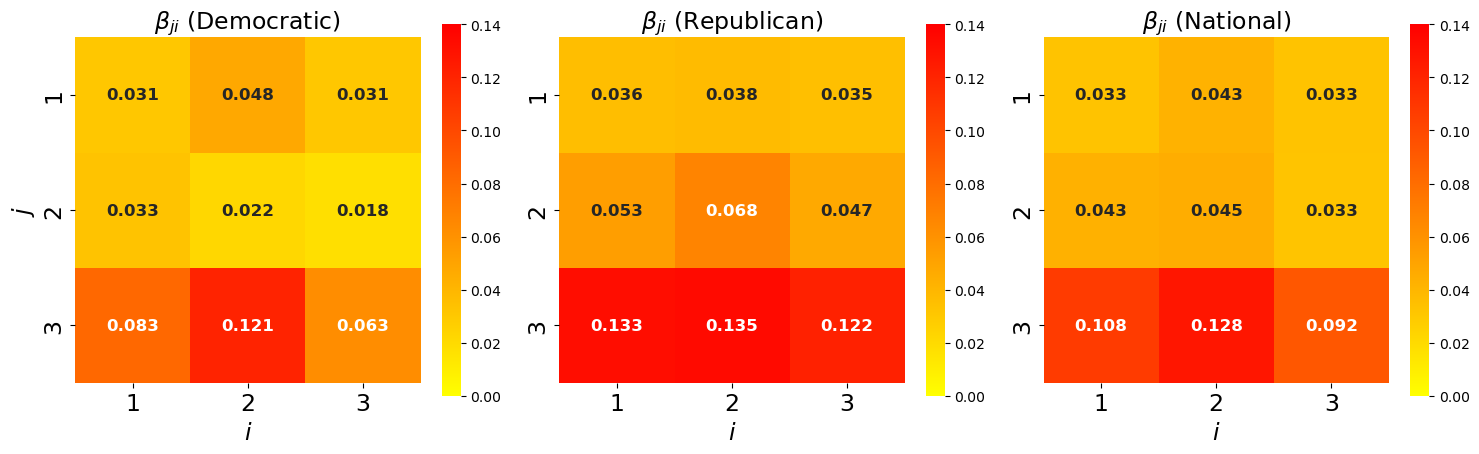

In [9]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import matplotlib.colors as mcolors
import seaborn as sns
dfa=pd.read_csv("paras-agemod2.csv")

color=dfa["politic"].values
color[color=="D"]="b"
color[color=="R"]="r"
col=['β11','β12','β13','β21','β22','β23','β31','β32','β33']
new_df = dfa[col]
new_df["C"]=color
averages = new_df.groupby('C').mean()  # Calculate mean for each group in 'C'
data = averages[col].to_numpy()
# Sample data (replace these with your actual 3x3 arrays)
x1 = data[0].reshape(3,3)
x2 = data[1].reshape(3,3)
x3 = (x1+x2)/2
  # You can use any base colormap here
norm = mcolors.Normalize(vmin=0, vmax=0.14)
# Create a figure with subplots
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# List of datasets and corresponding titles
datasets = [x1, x2, x3]
titles = [r"$\beta_{ji}$"+' (Democratic)',r"$\beta_{ji}$"+' (Republican)', r"$\beta_{ji}$"+' (National)']

# Loop through datasets and plot each one
for i, (data, ax) in enumerate(zip(datasets, axes)):
    # Compute the correlation matrix (for 3x3 matrix, it's just the matrix itself)
    corr_matrix = data
    
    # Create the heatmap with annotations
    sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='autumn_r',norm=norm, ax=ax,
                cbar_kws={'shrink': 0.8}, square=True, annot_kws={"size": 12, "weight": 'bold'})
    
    # Set the title and formatting
    ax.set_title(titles[i], fontsize=17)
    ax.set_xticklabels([1,2,3], fontsize=17)
    ax.set_yticklabels([1,2,3], fontsize=17)
    ax.set_xlabel(r'$i$', fontsize=17)
    if i==0:
        ax.set_ylabel(r'$j$', fontsize=17)

# Adjust layout for better spacing
plt.tight_layout()
plt.savefig("age_matrix.jpg",bbox_inches='tight',dpi=500)
plt.show()

In [7]:
averages

,β11,β12,β31,β21,β22,β23,β31,β32,β33
C,,,,,,,,,
b,0.030816,0.047665,0.082674,0.032850,0.022164,0.018006,0.082674,0.120853,0.062564
r,0.035788,0.037513,0.132775,0.053484,0.067555,0.047039,0.132775,0.134511,0.121638


In [5]:
data = averages[['β11','β12','β31']].to_numpy()
data

array([[0.03081637, 0.04766511, 0.08267438, 0.08267438],
       [0.03578774, 0.03751263, 0.13277484, 0.13277484]])

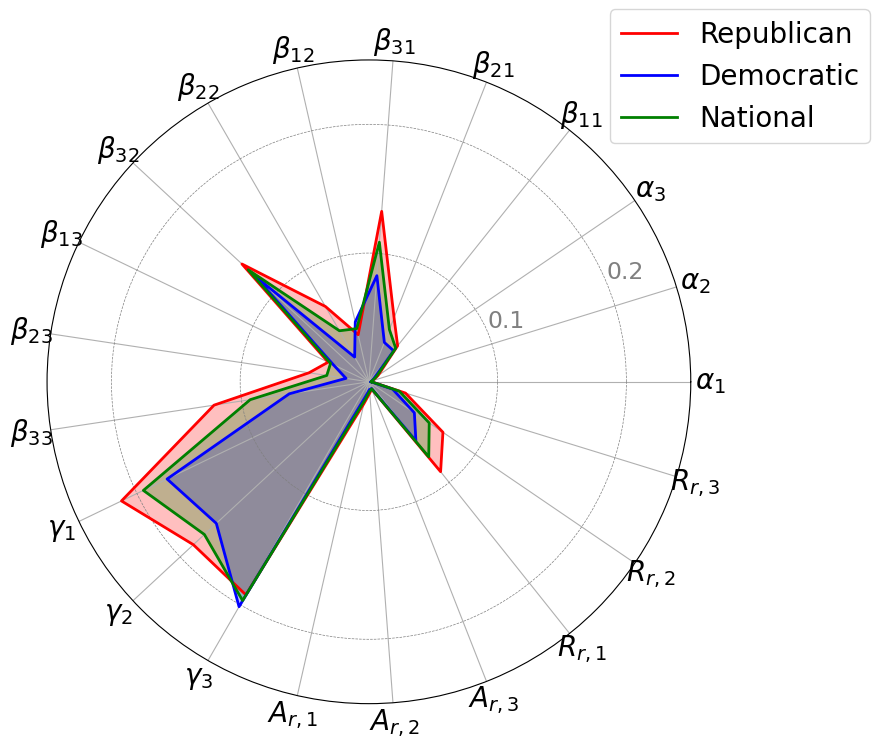

In [40]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Read data (replace with actual file paths)
dfa = pd.read_csv("paras-agemod2.csv")


# Map political affiliation to colors
color = dfa["politic"].values
color[color == "D"] = "b"
color[color == "R"] = "r"

# Columns to convert
columns_to_convert = [
    'α1', 'α2', 'α3', 'β11', 'β21', 'β31', 'β12', 'β22', 'β32',
    'β13', 'β23', 'β33', 'γ1', 'γ2', 'γ3', 'A_b1', 'A_b2', 'A_b3',
    'R_b1', 'R_b2', 'R_b3'
]
data = dfa[columns_to_convert].to_numpy()

# Aggregate data by affiliation
D = np.zeros(21)
R = np.zeros(21)
rr = 0
for i in range(50):
    if color[i] == "r":
        R += data[i, :]
        rr += 1
    else:
        D += data[i, :]

# Compute averages
data1 = R / rr
data2 = D / (50 - rr)
data3 = (D + R) / 50

# Labels for the parameters
labels = [
    r"$\alpha_1$", r"$\alpha_2$", r"$\alpha_3$", r"$\beta_{11}$", r"$\beta_{21}$", r"$\beta_{31}$",
    r"$\beta_{12}$", r"$\beta_{22}$", r"$\beta_{32}$", r"$\beta_{13}$", r"$\beta_{23}$", r"$\beta_{33}$",
    r"$\gamma_1$", r"$\gamma_2$", r"$\gamma_3$", r"$A_{r,1}$", r"$A_{r,2}$", r"$A_{r,3}$",
    r"$R_{r,1}$", r"$R_{r,2}$", r"$R_{r,3}$"
]

# Number of variables
num_vars = len(labels)

# Compute angles and extend data for closure
angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1]
data1 = np.append(data1, data1[0])
data2 = np.append(data2, data2[0])
data3 = np.append(data3, data3[0])

# Initialize the plot
fig, ax = plt.subplots(figsize=(9, 9), subplot_kw=dict(polar=True))

# Plot data
ax.plot(angles, data1, color='red', linewidth=2, label="Republican")
ax.fill(angles, data1, color='red', alpha=0.25)

ax.plot(angles, data2, color='blue', linewidth=2, label="Democratic")
ax.fill(angles, data2, color='blue', alpha=0.25)

ax.plot(angles, data3, color='green', linewidth=2, label="National")
ax.fill(angles, data3, color='green', alpha=0.25)

# Add axis labels
ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels, fontsize=20, color='black')
ax.xaxis.labelpad = 100
# Customize radial axis
ax.set_ylim(0, 0.25)
ax.set_yticks([0.1, 0.2])
ax.set_yticklabels(["0.1", "0.2"], fontsize=17, color='gray')
ax.yaxis.grid(color='gray', linestyle='--', linewidth=0.5)

# Title and legend
#ax.set_title("Comparison of Political Affiliation Parameters", fontsize=16, pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=20)

# Optimize layout and show the plot
plt.tight_layout()
plt.savefig("age_params.jpg",bbox_inches='tight',dpi=500)# Adjust layout to prevent clipping
plt.show()